In [3]:
import pandas as pd

customers = pd.read_csv("../exports/cleaned_data/customers_clean.csv")
orders = pd.read_csv("../exports/cleaned_data/orders_clean.csv")
order_items = pd.read_csv("../exports/cleaned_data/order_items_clean.csv")
products = pd.read_csv("../exports/cleaned_data/products_clean.csv")
inventory = pd.read_csv("../exports/cleaned_data/inventory_clean.csv")
inventory_new = pd.read_csv("../exports/cleaned_data/inventory_new_clean.csv")
delivery = pd.read_csv("../exports/cleaned_data/delivery_clean.csv")
feedback = pd.read_csv("../exports/cleaned_data/feedback_clean.csv")
marketing = pd.read_csv("../exports/cleaned_data/marketing_clean.csv")

In [4]:
customers["customer_segment"].value_counts()

customer_segment
Regular     639
Premium     633
New         628
Inactive    600
Name: count, dtype: int64

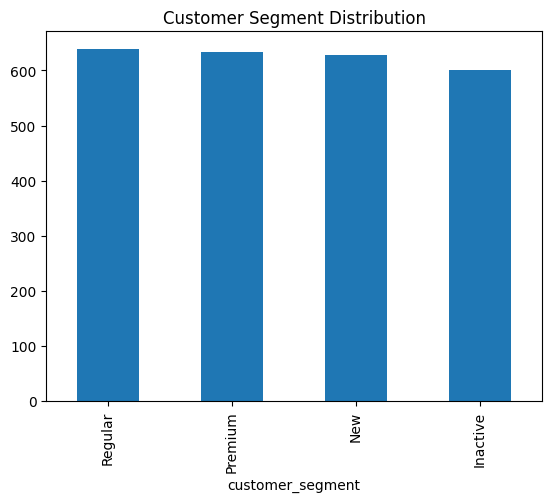

In [5]:
import matplotlib.pyplot as plt

customers["customer_segment"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Segment Distribution")
plt.show()

In [6]:
customers["total_orders"].describe()

count    2500.000000
mean       10.491600
std         5.805533
min         1.000000
25%         6.000000
50%        10.000000
75%        16.000000
max        20.000000
Name: total_orders, dtype: float64

In [7]:
customers["avg_order_value"].describe()

count    2500.000000
mean     1102.375836
std       523.043183
min       200.430000
25%       631.817500
50%      1118.650000
75%      1565.400000
max      1999.830000
Name: avg_order_value, dtype: float64

In [8]:
customers["registration_date"] = pd.to_datetime(
    customers["registration_date"]
)

customers["registration_month"] = (
    customers["registration_date"]
    .dt.to_period("M")
)

In [9]:
customers["area"].value_counts().head(10)

area
Jalna          18
Deoghar        17
Orai           17
Bathinda       17
Ratlam         16
Ghaziabad      16
Kishanganj     15
Nandyal        14
Kadapa         14
Gandhinagar    14
Name: count, dtype: int64

In [10]:
print("""
Business Insight:
...
""")


Business Insight:
...



In [11]:
orders.head()
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                5000 non-null   int64  
 1   customer_id             5000 non-null   int64  
 2   order_date              5000 non-null   object 
 3   promised_delivery_time  5000 non-null   object 
 4   actual_delivery_time    5000 non-null   object 
 5   delivery_status         5000 non-null   object 
 6   order_total             5000 non-null   float64
 7   payment_method          5000 non-null   object 
 8   delivery_partner_id     5000 non-null   int64  
 9   store_id                5000 non-null   int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 390.8+ KB


In [12]:
orders["order_date"] = pd.to_datetime(
    orders["order_date"]
)

In [13]:
orders["month"] = (
    orders["order_date"]
    .dt.to_period("M")
)

In [15]:
orders["delivery_delay"] = (
    pd.to_datetime(orders["actual_delivery_time"])
    - pd.to_datetime(orders["promised_delivery_time"])
)

In [16]:
product_sales = (
    order_items
    .merge(
        products,
        on="product_id",
        how="left"
    )
)

In [17]:
product_sales.head()

,order_id,product_id,quantity,unit_price,product_name,category,brand,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level
0,1961864118,642612,3,517.03,Pet Treats,Pet Care,Pillay-Ahuja,517.03,795.43,35.0,365,16,57
1,1549769649,378676,1,881.42,Orange Juice,Cold Drinks & Juices,Baral-Kamdar,881.42,1259.17,30.0,180,19,65
2,9185164487,741341,2,923.84,Eggs,Dairy & Breakfast,Prasad LLC,923.84,1154.80,20.0,7,13,62
3,9644738826,561860,1,874.78,Orange Juice,Cold Drinks & Juices,Gupta Ltd,874.78,1249.69,30.0,180,21,90
4,5427684290,602241,2,976.55,Nuts,Snacks & Munchies,Bahl-Pau,976.55,1502.38,35.0,90,12,75


In [18]:
inventory.head()

inventory_new.head()

,product_id,date,stock_received,damaged_stock
0,153019,Mar-23,4,1
1,848226,Mar-23,4,1
2,965755,Mar-23,1,0
3,39154,Mar-23,4,0
4,34186,Mar-23,3,1


In [19]:
delivery.head()

,order_id,delivery_partner_id,promised_time,actual_time,delivery_time_minutes,distance_km,delivery_status,reasons_if_delayed
0,1961864118,63230,2024-07-17 08:52:01,2024-07-17 08:47:01,-5.0,0.96,On Time,NaN
1,1549769649,14983,2024-05-28 13:25:29,2024-05-28 13:27:29,2.0,0.98,On Time,Traffic
2,9185164487,39859,2024-09-23 13:25:12,2024-09-23 13:29:12,4.0,3.83,On Time,Traffic
3,9644738826,61497,2023-11-24 16:34:56,2023-11-24 16:33:56,-1.0,2.76,On Time,NaN
4,5427684290,84315,2023-11-20 05:17:39,2023-11-20 05:18:39,1.0,2.63,On Time,Traffic


In [20]:
feedback.head()

,feedback_id,order_id,customer_id,rating,feedback_text,feedback_category,sentiment,feedback_date
0,2234710,1961864118,30065862,4,"It was okay, nothing special.",Delivery,Neutral,2024-07-17
1,5450964,1549769649,9573071,3,The order was incorrect.,App Experience,Negative,2024-05-28
2,482108,9185164487,45477575,3,"It was okay, nothing special.",App Experience,Neutral,2024-09-23
3,4823104,9644738826,88067569,4,The product met my expectations.,App Experience,Neutral,2023-11-24
4,3537464,5427684290,83298567,3,Product was damaged during delivery.,Delivery,Negative,2023-11-20


In [21]:
marketing.head()

,campaign_id,campaign_name,date,target_audience,channel,impressions,clicks,conversions,spend,revenue_generated,roas
0,548299,New User Discount,2024-11-05,Premium,App,3130,163,78,1431.85,4777.75,3.60
1,390914,Weekend Special,2024-11-05,Inactive,App,3925,494,45,4506.34,6238.11,2.98
2,834385,Festival Offer,2024-11-05,Inactive,Email,7012,370,78,4524.23,2621.00,2.95
3,241523,Flash Sale,2024-11-05,Inactive,SMS,1115,579,86,3622.79,2955.00,2.84
4,595111,Membership Drive,2024-11-05,New Users,Email,7172,795,54,2888.99,8951.81,2.22


In [22]:
customers["customer_segment"].value_counts()

customer_segment
Regular     639
Premium     633
New         628
Inactive    600
Name: count, dtype: int64

In [23]:
customers.groupby(
    "customer_segment"
)["avg_order_value"].mean().sort_values(
    ascending=False
)

customer_segment
New         1116.635557
Inactive    1102.150000
Premium     1101.473965
Regular     1089.467042
Name: avg_order_value, dtype: float64

In [24]:
customers.groupby(
    "customer_segment"
)["total_orders"].sum().sort_values(
    ascending=False
)

customer_segment
New         6829
Regular     6598
Premium     6452
Inactive    6350
Name: total_orders, dtype: int64

In [25]:
customers["area"].value_counts().head(10)

area
Jalna          18
Deoghar        17
Orai           17
Bathinda       17
Ratlam         16
Ghaziabad      16
Kishanganj     15
Nandyal        14
Kadapa         14
Gandhinagar    14
Name: count, dtype: int64

In [26]:
orders["order_total"].sum()

11009308.5

In [27]:
orders["order_total"].mean()

2201.8617

In [28]:
orders["delivery_status"].value_counts()

delivery_status
On Time                  3470
Slightly Delayed         1037
Significantly Delayed     493
Name: count, dtype: int64

In [29]:
orders["payment_method"].value_counts()

payment_method
Card      1285
Cash      1257
Wallet    1244
UPI       1214
Name: count, dtype: int64

In [30]:
orders.groupby(
    "store_id"
)["order_total"].sum().sort_values(
    ascending=False
)

store_id
523     6721.46
2409    6543.19
2334    6458.90
6124    6173.45
103     6161.48
         ...   
3813      22.14
539       22.04
3147      22.04
9922      13.25
8074      13.25
Name: order_total, Length: 5000, dtype: float64

In [31]:
product_sales = order_items.merge(
    products,
    on="product_id",
    how="left"
)

In [32]:
product_sales["revenue"] = (
    product_sales["quantity"]
    * product_sales["unit_price"]
)

In [33]:
product_sales.groupby(
    "category"
)["revenue"].sum().sort_values(
    ascending=False
)

category
Dairy & Breakfast        639222.19
Pharmacy                 592368.57
Fruits & Vegetables      559053.08
Pet Care                 539888.75
Household Care           444244.25
Personal Care            394894.61
Snacks & Munchies        394648.71
Cold Drinks & Juices     392717.62
Grocery & Staples        359937.82
Baby Care                348227.18
Instant & Frozen Food    307212.65
Name: revenue, dtype: float64

In [34]:
product_sales.groupby(
    "brand"
)["revenue"].sum().sort_values(
    ascending=False
)

brand
Karnik PLC                   65212.70
Mandal-Kar                   56464.65
Roy-Char                     55182.94
Sundaram Inc                 51830.35
Gole-Doshi                   51790.96
                               ...   
Arya, Sundaram and Pingle      752.76
Agate and Sons                 749.36
Toor-Nagar                     505.80
Chandran-Dass                  477.00
Warrior, Ravel and Amble       369.60
Name: revenue, Length: 267, dtype: float64

In [35]:
product_sales.groupby(
    "product_name"
)["revenue"].sum().sort_values(
    ascending=False
)

product_name
Vitamins             260822.01
Pet Treats           252007.37
Cough Syrup          203569.98
Toilet Cleaner       199837.48
Bread                184851.10
Dish Soap            184441.21
Cat Food             166596.39
Baby Wipes           158768.41
Onions               138858.42
Baby Food            137442.79
Eggs                 137396.83
Lotion               136400.42
Cola                 132367.36
Biscuits             128354.32
Pain Reliever        127976.58
Dog Food             121284.99
Carrots              120499.25
Frozen Biryani       111562.12
Soap                 110906.63
Butter               106843.34
Orange Juice         106443.82
Sugar                103884.76
Toothpaste            97911.67
Pulses                94641.06
Mangoes               94339.05
Potatoes              92859.84
Wheat Flour           92791.66
Cheese                78519.56
Curd                  74055.08
Iced Tea              71171.24
Mango Drink           67757.40
Nuts                  6702

In [36]:
inventory["stock_received"].sum()

147526

In [37]:
inventory["damaged_stock"].sum()

80268

In [38]:
(
inventory["damaged_stock"].sum()
/
inventory["stock_received"].sum()
) * 100

54.40939224272332

In [39]:
inventory_products = inventory.merge(
    products,
    on="product_id",
    how="left"
)

In [40]:
inventory_products.groupby(
    "product_name"
)["damaged_stock"].sum().sort_values(
    ascending=False
)

product_name
Pet Treats           3494
Toilet Cleaner       3030
Dish Soap            3022
Lotion               3016
Vitamins             2940
Cough Syrup          2620
Baby Wipes           2484
Pulses               2482
Detergent            2158
Bread                2122
Eggs                 2120
Cat Food             2116
Biscuits             2098
Orange Juice         2082
Potatoes             2080
Cola                 2076
Frozen Biryani       1962
Dog Food             1918
Onions               1812
Pain Reliever        1806
Baby Food            1756
Soap                 1544
Frozen Pizza         1534
Carrots              1522
Toothpaste           1516
Popcorn              1516
Wheat Flour          1470
Shampoo              1448
Sugar                1434
Cheese               1412
Curd                 1216
Mango Drink          1212
Chips                1200
Chocolates           1200
Nuts                 1194
Butter               1154
Bananas               954
Frozen Vegetables     954

In [41]:
delivery["delivery_time_minutes"].mean()

4.443

In [42]:
delivery["delivery_status"].value_counts()

delivery_status
On Time                  3470
Slightly Delayed         1037
Significantly Delayed     493
Name: count, dtype: int64

In [43]:
delivery["distance_km"].mean()

2.7180480000000005

In [44]:
delivery["reasons_if_delayed"].value_counts()

reasons_if_delayed
Traffic    3098
Name: count, dtype: int64

In [45]:
feedback["rating"].value_counts()

rating
4    1708
3    1398
5     816
1     540
2     538
Name: count, dtype: int64

In [46]:
feedback["sentiment"].value_counts()

sentiment
Neutral     1738
Negative    1642
Positive    1620
Name: count, dtype: int64

In [47]:
feedback["feedback_category"].value_counts()

feedback_category
Delivery            1271
Customer Service    1266
Product Quality     1250
App Experience      1213
Name: count, dtype: int64

In [48]:
marketing.groupby(
    "channel"
)[
    ["spend",
     "revenue_generated",
     "conversions"]
].sum()

,spend,revenue_generated,conversions
channel,,,
App,4213378.75,8075010.49,75192
Email,3997488.04,8189331.58,74671
SMS,3998607.54,7938649.32,73235
Social Media,4110363.91,7990415.98,74940


In [49]:
marketing.groupby(
    "campaign_name"
)["roas"].mean().sort_values(
    ascending=False
)

campaign_name
Email Campaign           2.777067
Festival Offer           2.765917
App Push Notification    2.760817
New User Discount        2.754950
Referral Program         2.743450
Weekend Special          2.743333
Membership Drive         2.719833
Flash Sale               2.711067
Category Promotion       2.689967
Name: roas, dtype: float64

In [50]:
marketing.groupby(
    "target_audience"
)["revenue_generated"].sum().sort_values(
    ascending=False
)

target_audience
New Users    8142498.88
Inactive     8105791.01
All          7978638.29
Premium      7966479.19
Name: revenue_generated, dtype: float64

In [51]:
customer_revenue = (
    customers[[
        "customer_id",
        "customer_segment"
    ]]
    .merge(
        orders[[
            "customer_id",
            "order_total"
        ]],
        on="customer_id",
        how="inner"
    )
)

In [52]:
segment_revenue = (
    customer_revenue
    .groupby("customer_segment")
    ["order_total"]
    .sum()
    .sort_values(ascending=False)
)

segment_revenue

customer_segment
Regular     2890148.66
New         2795854.48
Premium     2731329.71
Inactive    2591975.65
Name: order_total, dtype: float64

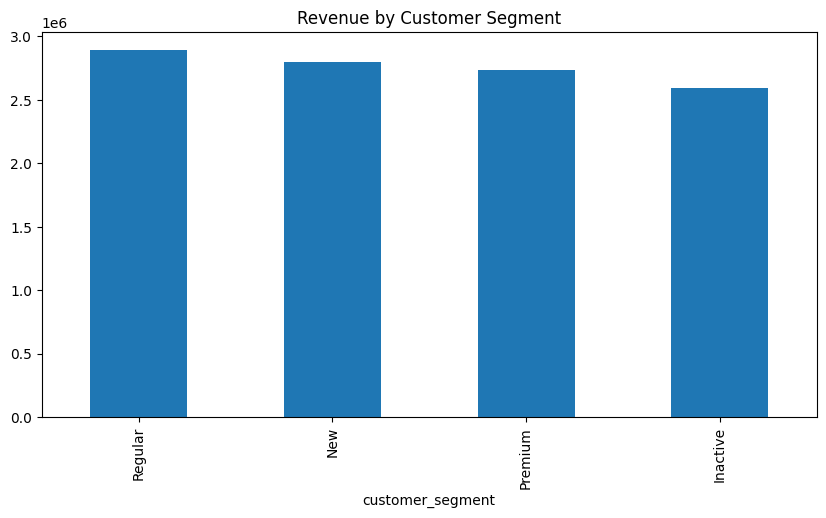

In [53]:
segment_revenue.plot(
    kind="bar",
    figsize=(10,5)
)
plt.title("Revenue by Customer Segment")
plt.show()

In [54]:
segment_feedback = (
    feedback.merge(
        customers[[
            "customer_id",
            "customer_segment"
        ]],
        on="customer_id",
        how="left"
    )
)

In [55]:
segment_feedback.groupby(
    "customer_segment"
)["rating"].mean().sort_values(
    ascending=False
)

customer_segment
Inactive    3.366387
Regular     3.351515
New         3.339607
Premium     3.320978
Name: rating, dtype: float64

In [56]:
delivery_feedback = (
    delivery.merge(
        feedback,
        on="order_id",
        how="inner"
    )
)

In [57]:
delivery_feedback[
    [
        "delivery_time_minutes",
        "rating"
    ]
].corr()

,delivery_time_minutes,rating
delivery_time_minutes,1.00000,0.00017
rating,0.00017,1.00000


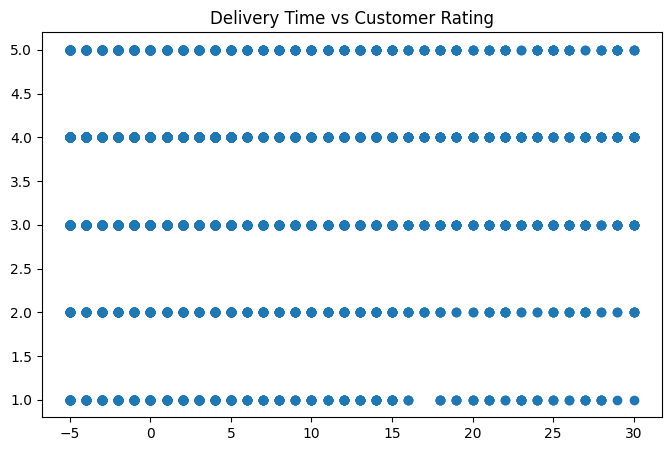

In [58]:
plt.figure(figsize=(8,5))

plt.scatter(
    delivery_feedback["delivery_time_minutes"],
    delivery_feedback["rating"]
)

plt.title(
    "Delivery Time vs Customer Rating"
)

plt.show()

In [59]:
product_sales = (
    order_items
    .merge(
        products,
        on="product_id",
        how="left"
    )
)

product_sales["revenue"] = (
    product_sales["quantity"]
    *
    product_sales["unit_price"]
)

In [60]:
category_revenue = (
    product_sales.groupby(
        "category"
    )["revenue"]
    .sum()
)

In [61]:
inventory_products = (
    inventory
    .merge(
        products,
        on="product_id",
        how="left"
    )
)

category_inventory = (
    inventory_products.groupby(
        "category"
    )["stock_received"]
    .sum()
)

In [62]:
category_comparison = pd.concat(
    [
        category_revenue,
        category_inventory
    ],
    axis=1
)

category_comparison

,revenue,stock_received
category,,
Baby Care,348227.18,9700
Cold Drinks & Juices,392717.62,11107
Dairy & Breakfast,639222.19,14873
Fruits & Vegetables,559053.08,13670
Grocery & Staples,359937.82,15036
Household Care,444244.25,12034
Instant & Frozen Food,307212.65,10183
Personal Care,394894.61,12239
Pet Care,539888.75,17521


In [63]:
channel_summary = (
    marketing.groupby(
        "channel"
    )
    [
        [
            "spend",
            "revenue_generated",
            "conversions"
        ]
    ]
    .sum()
)

channel_summary

,spend,revenue_generated,conversions
channel,,,
App,4213378.75,8075010.49,75192
Email,3997488.04,8189331.58,74671
SMS,3998607.54,7938649.32,73235
Social Media,4110363.91,7990415.98,74940


In [64]:
channel_summary["roi"] = (
    (
        channel_summary["revenue_generated"]
        -
        channel_summary["spend"]
    )
    /
    channel_summary["spend"]
) * 100

In [65]:
product_revenue = (
    product_sales.groupby(
        "product_name"
    )["revenue"]
    .sum()
    .sort_values(
        ascending=False
    )
)

In [66]:
pareto = (
    product_revenue
    .reset_index()
)

pareto["cum_pct"] = (
    pareto["revenue"]
    .cumsum()
    /
    pareto["revenue"].sum()
) * 100

In [67]:
print("""
EDA Completed Successfully

Key Business Domains Analyzed:
✓ Customer Intelligence
✓ Revenue Intelligence
✓ Product Intelligence
✓ Inventory Intelligence
✓ Delivery Intelligence
✓ Marketing Intelligence
✓ Cross-Domain Insights
""")


EDA Completed Successfully

Key Business Domains Analyzed:
✓ Customer Intelligence
✓ Revenue Intelligence
✓ Product Intelligence
✓ Inventory Intelligence
✓ Delivery Intelligence
✓ Marketing Intelligence
✓ Cross-Domain Insights



In [68]:
%whos

Variable              Type         Data/Info
--------------------------------------------
category_comparison   DataFrame                             <...>394648.71           13845
category_inventory    Series       category\nBaby Care      <...>ck_received, dtype: int64
category_revenue      Series       category\nBaby Care      <...>: revenue, dtype: float64
channel_summary       DataFrame                       spend <...>        74940   94.396802
customer_revenue      DataFrame          customer_id custome<...>\n[5000 rows x 3 columns]
customers             DataFrame          customer_id      cu<...>n[2500 rows x 12 columns]
delivery              DataFrame            order_id  deliver<...>\n[5000 rows x 8 columns]
delivery_feedback     DataFrame            order_id  deliver<...>n[5000 rows x 15 columns]
feedback              DataFrame          feedback_id    orde<...>\n[5000 rows x 8 columns]
inventory             DataFrame           product_id        <...>n[75172 rows x 4 columns]


In [69]:
output_path = "../exports/processed_data/"

In [70]:
segment_revenue.reset_index().to_csv(
    output_path + "segment_revenue.csv",
    index=False
)

In [71]:
segment_feedback.groupby(
    "customer_segment"
)["rating"].mean().reset_index().to_csv(
    output_path + "segment_satisfaction.csv",
    index=False
)

In [72]:
delivery_feedback.to_csv(
    output_path + "delivery_feedback_analysis.csv",
    index=False
)

In [73]:
category_comparison.reset_index().to_csv(
    output_path + "category_inventory_comparison.csv",
    index=False
)

In [74]:
channel_summary.reset_index().to_csv(
    output_path + "marketing_channel_summary.csv",
    index=False
)

In [75]:
pareto.to_csv(
    output_path + "pareto_analysis.csv",
    index=False
)

In [76]:
customer_summary = customers.groupby(
    "customer_segment"
).agg({
    "customer_id":"count",
    "total_orders":"sum",
    "avg_order_value":"mean"
}).reset_index()

customer_summary.to_csv(
    output_path + "customer_summary.csv",
    index=False
)

In [77]:
product_summary = product_sales.groupby(
    "category"
).agg({
    "revenue":"sum",
    "quantity":"sum"
}).reset_index()

product_summary.to_csv(
    output_path + "product_summary.csv",
    index=False
)

In [78]:
inventory_summary = inventory_products.groupby(
    "category"
).agg({
    "stock_received":"sum",
    "damaged_stock":"sum"
}).reset_index()

inventory_summary.to_csv(
    output_path + "inventory_summary.csv",
    index=False
)

In [79]:
marketing_summary = marketing.groupby(
    "channel"
).agg({
    "spend":"sum",
    "revenue_generated":"sum",
    "conversions":"sum",
    "roas":"mean"
}).reset_index()

marketing_summary.to_csv(
    output_path + "marketing_summary.csv",
    index=False
)

In [80]:
import os

os.listdir("../exports/processed_data")

['category_inventory_comparison.csv',
 'customer_summary.csv',
 'delivery_feedback_analysis.csv',
 'inventory_summary.csv',
 'marketing_channel_summary.csv',
 'marketing_summary.csv',
 'pareto_analysis.csv',
 'product_summary.csv',
 'segment_revenue.csv',
 'segment_satisfaction.csv']